In [6]:
from moviepy.editor import AudioFileClip, VideoClip
import numpy as np

fps = 25

tensor = np.ones((768,20,20,3)).astype(np.uint8)


def make_frame(t):
# get index
    frame_index = min(int(t * fps), tensor.shape[0] - 1)
    return tensor[frame_index]
print(f"final_f = {tensor.shape}")

new_video_clip = VideoClip(make_frame, duration=tensor.shape[0] / fps)
audio_clip = AudioFileClip("/home/saeed/sample1_1.wav").subclip(0, tensor.shape[0] / fps)
new_video_clip = new_video_clip.set_audio(audio_clip)
new_video_clip.write_videofile("/home/saeed/x.mp4", fps=fps, audio_codec='aac')

chunk:  82%|████████▏ | 555/678 [00:45<00:00, 2500.26it/s, now=None]

final_f = (768, 20, 20, 3)
Moviepy - Building video /home/saeed/x.mp4.
MoviePy - Writing audio in xTEMP_MPY_wvf_snd.mp4


chunk:  82%|████████▏ | 555/678 [00:45<00:00, 2500.26it/s, now=None]

MoviePy - Done.
Moviepy - Writing video /home/saeed/x.mp4



chunk:  82%|████████▏ | 555/678 [00:45<00:00, 2500.26it/s, now=None]

Moviepy - Done !
Moviepy - video ready /home/saeed/x.mp4


In [5]:
from decord import VideoReader, cpu

video_frames = VideoReader("/hame/saeed/Downloads/ch_long_prep.mp4", ctx=cpu(0))

[13:49:51] /github/workspace/src/video/video_reader.cc:83: ERROR opening: /hame/saeed/Downloads/ch_long_prep.mp4, No such file or directory


RuntimeError: Error reading /hame/saeed/Downloads/ch_long_prep.mp4...

In [7]:
import cv2

img_cv2 = cv2.imread("/home/saeed/me.jpg")
img_cv2_rgb = cv2.cvtColor(img_cv2, cv2.COLOR_BGR2RGB)

In [10]:
img_cv2[1,1]

array([ 81, 100, 107], dtype=uint8)

In [11]:
img_cv2_rgb[1,1]

array([107, 100,  81], dtype=uint8)

In [12]:
img_cv2_rgb_rgb = cv2.cvtColor(img_cv2_rgb, cv2.COLOR_BGR2RGB)
img_cv2_rgb_rgb[1,1]

array([ 81, 100, 107], dtype=uint8)

In [8]:
from PIL import Image
img_pil = Image.fromarray(img_cv2).convert("RGB")
img_pil_rgb = Image.fromarray(img_cv2_rgb).convert("RGB")

In [16]:
import numpy as np
np.asarray(img_pil)[1,1]

array([ 81, 100, 107], dtype=uint8)

In [17]:
np.asanyarray(Image.fromarray(img_cv2))[1,1]

array([ 81, 100, 107], dtype=uint8)

In [18]:
np.asanyarray(Image.fromarray(img_cv2).convert("RGB"))[1,1]

array([ 81, 100, 107], dtype=uint8)

In [19]:
np.asanyarray(Image.fromarray(img_cv2_rgb))[1,1]

array([107, 100,  81], dtype=uint8)

In [20]:
np.asanyarray(img_pil_rgb)[1,1]

array([107, 100,  81], dtype=uint8)

In [21]:
x = cv2.imread("/home/saeed/me.jpg")

y = Image.open("/home/saeed/me.jpg")

In [22]:
x[1,1]

array([ 81, 100, 107], dtype=uint8)

In [23]:
np.asanyarray(y)[1,1]

array([107, 100,  81], dtype=uint8)

In [10]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

mask = cv2.imread("../hallo_speax_train/model_ckpts/mask_512_big.png")

video = cv2.VideoCapture("./m.mp4")

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
video_write = cv2.VideoWriter("./m_mask_big.mp4", fourcc, 25, (512,512))  # 30 FPS

_, frame = video.read()

cv2.imwrite("./d.png", frame)

while 1:
    still_reading, frame = video.read()
    if not still_reading:
        break

    frame_mask = np.array((mask/255.)*frame, dtype=(np.uint8))
    video_write.write(frame_mask)

video_write.release()
video.release()

In [8]:
video_write.release()

In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
mask = cv2.imread("./model_ckpts/mask_64_big.png")

# plt.imshow(mask)

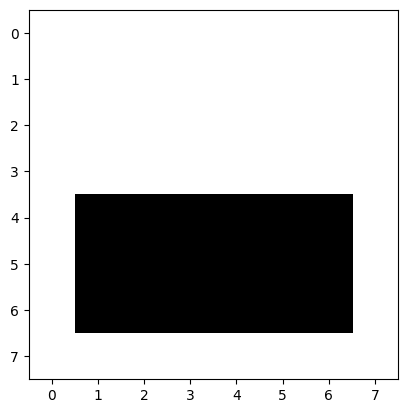

In [44]:
resized_mask = cv2.resize(mask, (8, 8), interpolation=cv2.INTER_LINEAR)
plt.imshow(resized_mask)

In [43]:
k = 8
mask = cv2.imread(f"./mask_{k}.png")
for i in range(k):
    for j in range(k):
        if any(mask[i,j]!=(0,0,0)) and any(mask[i,j]!=(255,255,255)):
            print(i, j)


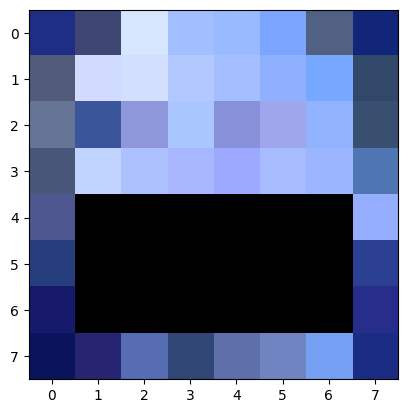

In [50]:
k = 8
img = cv2.resize(cv2.imread("./s6.png"), (k,k))
# mask_512 = cv2.imread("./model_ckpts/mask_512_big.png")
mask_512_new = cv2.imread(f"./mask_{k}.png")
plt.imshow(np.array((mask_512_new/255.)*img, dtype=(np.uint8)))

In [34]:
import numpy as np

#512
mask_512 = np.array(np.ones((512,512,3), dtype=np.uint8) * 255, dtype=np.uint8)
mask_512[224:-32, 40:-40, :] = 0
cv2.imwrite("./mask_512.png", mask_512)

#64
mask_64 = np.array(np.ones((64,64,3), dtype=np.uint8) * 255, dtype=np.uint8)
mask_64[28:-4, 5:-5, :] = 0
cv2.imwrite("./mask_64.png", mask_64)

#32
mask_32 = np.array(np.ones((32,32,3), dtype=np.uint8) * 255, dtype=np.uint8)
mask_32[14:-2, 3:-3, :] = 0
cv2.imwrite("./mask_32.png", mask_32)

#16
mask_16 = np.array(np.ones((16,16,3), dtype=np.uint8) * 255, dtype=np.uint8)
mask_16[7:-1, 2:-2, :] = 0
cv2.imwrite("./mask_16.png", mask_16)

#8
mask_8 = np.array(np.ones((8,8,3), dtype=np.uint8) * 255, dtype=np.uint8)
mask_8[4:-1, 1:-1, :] = 0
cv2.imwrite("./mask_8.png", mask_8)

True

In [29]:
import numpy as np
import torch

x = np.array([[1,2,3], [3,4,5]])
x = np.random.rand(2,3,4)

d = torch.randn(2,3,4)
t = d.repeat(1,2,1)
y = x.repeat(1,2,1)

TypeError: repeat() takes at most 2 arguments (3 given)

In [3]:
import torch
import cv2


b = 1
f = 12
c_512, c_64, c_32, c_16, c_8 = 10,10,10,10,10

c_new = 10
mask_path = "./model_ckpts/mask_512.png"
# def create_mask(mask_path, b, c_new, f):
mask = torch.FloatTensor(1 - (cv2.imread(mask_path) / 255.))
(h, w, c) = mask.shape
mask_new = torch.zeros((h,w,c_new))
mask_new[:, :, :c] = mask
mask_new[:, :, c:] = mask[:, :, c-1:c].repeat(1,1,c_new-c)

mask_new = mask_new.permute(2,0,1).unsqueeze(1).unsqueeze(0) # 1*c*1*h*w

mask_new = mask_new.repeat(b, 1, f, 1, 1) # b*c*f*h*w

# return mask

    
# x = create_mask("./model_ckpts/mask_512.png", b, c_512, f)

In [ ]:
mask_new.to("cuda")

In [5]:
mask_new.dtype

torch.float32

In [13]:
from decord import VideoReader, cpu
from PIL import Image

video_frames = VideoReader("/home/saeed/s10_wav2lip.mp4", ctx=cpu(0))

frame_list = [Image.fromarray(video).convert("RGB") for video in video_frames[:10].asnumpy()]


In [8]:
video_frames.shape

(10, 1080, 1920, 3)

In [12]:
video_frames[0]

TypeError: 'NDArray' object is not subscriptable

In [1]:
from einops import rearrange
import torch

x = torch.zeros((2,4,12,64,64))
video_length = x.shape[2]
x = rearrange(x, "b c f h w -> (b f) c h w")
# x = super().forward(x)
x = rearrange(x, "(b f) c h w -> b c f h w", f=video_length)


In [17]:
import json 
import os

with open('./echo_val_1000.json', 'r') as f:
    data = json.load(f)

files = os.listdir("/home/saeed/Downloads/dataset/dataset_1000")

new_data = []
for item in data:
    if (item["video_path"].split("/")[-1] in files):
        new_data.append(item) 

with open('/home/saeed/Downloads/echo_val_1000_clean.json', 'w') as f:
    json.dump(data, f, indent=4)

In [18]:
len(data)

100

In [18]:
import numpy as np
x = [(568, 187, 689, 354), (566, 187, 686, 353), (565, 187, 685, 353), (562, 186, 682, 353), (558, 185, 676, 351), (554, 182, 672, 348), (552, 181, 669, 344), (550, 180, 667, 343), (549, 180, 665, 346), (548, 179, 663, 344), (546, 177, 662, 340), (544, 173, 661, 334), (542, 169, 656, 329), (541, 165, 654, 322), (539, 162, 651, 317), (537, 159, 649, 314), (535, 157, 645, 310), (532, 155, 643, 309), (529, 156, 639, 308), (527, 157, 635, 309), (525, 155, 634, 306), (524, 155, 631, 301), (524, 154, 632, 298), (526, 155, 632, 299), (527, 157, 633, 301), (532, 159, 638, 302), (539, 157, 645, 304), (543, 157, 647, 304), (548, 157, 651, 303), (552, 157, 654, 299), (558, 159, 659, 298), (566, 159, 666, 297), (572, 160, 672, 299), (582, 161, 680, 298), (589, 161, 687, 301), (598, 162, 695, 304), (601, 165, 699, 306), (603, 165, 699, 304), (603, 167, 699, 302), (604, 167, 700, 300), (605, 167, 701, 300), (605, 167, 701, 303), (606, 167, 701, 302), (606, 168, 701, 303), (605, 171, 700, 306), (604, 174, 700, 308), (603, 179, 699, 312), (601, 184, 698, 315), (600, 187, 697, 317), (599, 188, 696, 318), (599, 189, 695, 318), (599, 188, 695, 317), (599, 188, 695, 316), (599, 187, 695, 316), (599, 186, 695, 314), (599, 186, 695, 313), (600, 183, 695, 311), (602, 183, 697, 311), (603, 182, 698, 310), (603, 181, 697, 307), (605, 179, 699, 304), (606, 177, 700, 303), (608, 175, 701, 300), (609, 174, 701, 298), (611, 173, 702, 298), (612, 171, 704, 295), (613, 170, 703, 294), (614, 168, 707, 291), (616, 168, 708, 291), (616, 167, 708, 290), (616, 166, 709, 289), (616, 165, 709, 288), (618, 163, 710, 287), (618, 162, 710, 287), (618, 161, 711, 287), (618, 158, 711, 284), (617, 157, 711, 284), (617, 155, 711, 283), (617, 154, 711, 283), (617, 154, 711, 283), (617, 154, 711, 282), (617, 154, 711, 282), (616, 155, 711, 282), (615, 155, 710, 282), (614, 154, 709, 283), (612, 154, 706, 282), (610, 155, 704, 283), (607, 156, 703, 286), (605, 159, 701, 289), (604, 162, 701, 293), (602, 167, 699, 298), (598, 170, 696, 299), (595, 173, 693, 304), (592, 175, 693, 307), (590, 178, 690, 311), (589, 180, 688, 313), (585, 181, 685, 316), (583, 183, 685, 318), (582, 184, 684, 320), (581, 185, 683, 321), (580, 186, 683, 323), (575, 187, 679, 325), (571, 190, 677, 326), (568, 190, 675, 326), (567, 193, 673, 331), (566, 192, 674, 333), (564, 193, 673, 335), (563, 193, 670, 335), (559, 195, 667, 335), (556, 195, 664, 335), (553, 192, 665, 334), (550, 191, 663, 334), (546, 189, 659, 337), (542, 189, 655, 337), (536, 187, 652, 336), (534, 188, 652, 336), (530, 187, 650, 336), (527, 187, 647, 335), (523, 186, 643, 336), (520, 186, 641, 338), (518, 184, 638, 337), (517, 183, 637, 337), (516, 182, 635, 336), (515, 179, 637, 338), (516, 178, 639, 338), (518, 177, 642, 338), (520, 177, 646, 339), (523, 176, 649, 339), (526, 173, 651, 336), (531, 172, 656, 335), (534, 170, 662, 334), (533, 84, 697, 315), (535, 82, 699, 315), (537, 82, 703, 317), (539, 84, 711, 322), (543, 85, 713, 330), (546, 87, 716, 335), (548, 89, 721, 338), (551, 93, 726, 341), (552, 96, 728, 344), (553, 101, 732, 351), (554, 105, 732, 356), (555, 109, 735, 363), (555, 112, 739, 368), (556, 114, 741, 374), (556, 118, 741, 377), (557, 119, 745, 378), (560, 121, 747, 379), (561, 121, 747, 380), (563, 121, 752, 381), (565, 121, 757, 381), (566, 118, 757, 377), (567, 116, 758, 377), (567, 115, 759, 378), (567, 114, 759, 382), (566, 113, 759, 383), (566, 112, 760, 381), (565, 110, 760, 378), (563, 108, 757, 378), (562, 109, 756, 377), (561, 105, 754, 376), (558, 104, 750, 376), (555, 105, 748, 376), (553, 105, 748, 373), (550, 105, 746, 374), (548, 104, 744, 374), (543, 104, 742, 379), (550, 219, 708, 417), (547, 240, 706, 432), (545, 263, 701, 451), (543, 283, 697, 465), (539, 298, 693, 472), (533, 312, 686, 474), (531, 313, 683, 474), (529, 311, 682, 470), (528, 308, 679, 468), (527, 304, 676, 462), (526, 301, 678, 459), (524, 296, 677, 454), (523, 291, 676, 452), (524, 286, 676, 448), (526, 284, 675, 444), (528, 278, 676, 436), (531, 270, 675, 432), (532, 264, 679, 427), (535, 255, 681, 420), (538, 248, 683, 416), (540, 240, 684, 406), (543, 233, 684, 400), (545, 228, 687, 392), (546, 216, 688, 384), (546, 207, 688, 375), (548, 198, 687, 368), (550, 187, 689, 361), (552, 177, 690, 349), (554, 171, 691, 341), (555, 160, 691, 333), (557, 153, 691, 328), (560, 144, 691, 320), (564, 135, 695, 308), (570, 125, 696, 293), (574, 117, 698, 285), (578, 108, 700, 277), (581, 103, 702, 273), (610, 100, 723, 257), (613, 106, 725, 261), (615, 112, 726, 265), (616, 119, 726, 272), (617, 128, 725, 277), (618, 135, 724, 282), (618, 139, 723, 286), (620, 141, 724, 286), (621, 144, 724, 287), (621, 146, 725, 288), (622, 149, 725, 286), (625, 153, 726, 289), (627, 157, 729, 296), (629, 162, 728, 301), (630, 166, 728, 303), (631, 170, 729, 306), (632, 177, 729, 312), (631, 182, 728, 317), (630, 185, 726, 318), (629, 186, 725, 319), (627, 186, 723, 318), (624, 187, 720, 317), (622, 185, 717, 314), (621, 185, 715, 315), (619, 185, 712, 314), (616, 183, 710, 312), (614, 182, 707, 311), (611, 182, 702, 309), (609, 182, 701, 310), (607, 182, 700, 309), (606, 183, 698, 306), (606, 183, 696, 304), (605, 183, 694, 304), (604, 184, 693, 306), (605, 185, 694, 309), (604, 185, 693, 306), (605, 187, 694, 308), (605, 187, 694, 311), (606, 188, 694, 311), (606, 188, 694, 309), (606, 188, 693, 307), (607, 187, 694, 306), (606, 188, 693, 307), (607, 187, 694, 309), (607, 187, 694, 310), (607, 187, 695, 310), (607, 186, 696, 309), (607, 186, 696, 308), (609, 186, 697, 308), (610, 186, 698, 307), (610, 185, 698, 305), (610, 185, 699, 305), (610, 184, 699, 304), (611, 184, 699, 304), (612, 183, 699, 304), (613, 182, 701, 303), (613, 181, 701, 303), (610, 177, 698, 300), (607, 176, 695, 298), (606, 175, 694, 295), (604, 175, 691, 296), (604, 174, 690, 293), (604, 174, 690, 293), (604, 174, 690, 294), (603, 173, 691, 294), (604, 174, 692, 296), (605, 174, 694, 297), (605, 174, 694, 299), (605, 172, 695, 301), (605, 170, 698, 301), (606, 168, 702, 302), (606, 166, 706, 303), (605, 162, 710, 304), (605, 162, 712, 308), (605, 164, 714, 313), (605, 166, 717, 318), (607, 168, 719, 322), (608, 171, 721, 324), (611, 173, 725, 325), (613, 174, 727, 325), (616, 177, 731, 327), (619, 177, 733, 330), (620, 179, 735, 336), (621, 177, 740, 338), (623, 177, 742, 339), (625, 176, 743, 338), (626, 177, 743, 339), (626, 177, 744, 338), (627, 177, 746, 337), (626, 177, 745, 337), (625, 177, 744, 338), (622, 177, 743, 338), (620, 175, 741, 338), (614, 173, 733, 336), (605, 166, 726, 332), (598, 160, 717, 326), (593, 156, 713, 325), (589, 154, 710, 322), (584, 148, 707, 319), (580, 147, 702, 317), (578, 145, 701, 315), (575, 143, 700, 313), (574, 143, 699, 313), (573, 142, 699, 313), (572, 142, 697, 313), (568, 141, 695, 315), (567, 141, 694, 316), (563, 140, 692, 316), (562, 142, 691, 318), (561, 143, 691, 321), (561, 145, 692, 324), (562, 148, 695, 325), (565, 150, 697, 327), (565, 152, 698, 333), (564, 155, 697, 337), (562, 156, 696, 338), (561, 158, 697, 340), (560, 159, 697, 342), (559, 160, 697, 344), (556, 162, 696, 347), (554, 162, 694, 349), (552, 163, 693, 350), (552, 164, 694, 351), (551, 165, 693, 354), (549, 164, 692, 355), (547, 165, 691, 355), (545, 166, 690, 356), (545, 167, 691, 357), (546, 166, 693, 360), (547, 167, 695, 361), (547, 167, 696, 359), (550, 167, 697, 359), (553, 167, 699, 359), (555, 166, 702, 354), (558, 165, 708, 355), (561, 164, 712, 358), (565, 165, 715, 359), (570, 165, 719, 360), (574, 163, 725, 359), (577, 162, 728, 360), (578, 159, 730, 360), (582, 158, 731, 358), (584, 156, 735, 359), (586, 154, 739, 357), (589, 153, 742, 355), (592, 153, 745, 354), (595, 151, 747, 353), (599, 150, 750, 351), (602, 148, 754, 353), (605, 148, 758, 357), (607, 147, 762, 357), (607, 147, 761, 355), (606, 144, 761, 352), (605, 142, 761, 349), (604, 142, 760, 352), (603, 142, 759, 353), (602, 140, 758, 352), (602, 140, 758, 350), (600, 139, 756, 349), (600, 137, 757, 348), (598, 137, 755, 349), (598, 136, 754, 352), (596, 135, 751, 352), (593, 133, 749, 350), (592, 133, 747, 344), (593, 132, 748, 340), (593, 131, 748, 341), (592, 131, 747, 344), (591, 131, 745, 346), (592, 130, 747, 345), (592, 128, 748, 341), (592, 127, 748, 340), (586, 115, 740, 330), (583, 115, 736, 328), (582, 110, 735, 322), (582, 106, 735, 318), (582, 104, 734, 316), (582, 102, 734, 312), (582, 101, 734, 308), (583, 100, 734, 307), (584, 101, 734, 308), (583, 100, 733, 308), (582, 102, 731, 308), (582, 104, 729, 308), (582, 105, 728, 308), (579, 107, 726, 310), (576, 111, 719, 312), (575, 116, 716, 312), (573, 119, 712, 312), (571, 121, 709, 313), (569, 123, 702, 317), (556, 127, 686, 305), (554, 126, 683, 304), (552, 126, 681, 308), (549, 127, 679, 308), (548, 132, 677, 309), (548, 137, 676, 309), (548, 143, 676, 314), (548, 151, 675, 320), (548, 164, 676, 332), (549, 174, 676, 338), (549, 180, 676, 344), (550, 191, 677, 351), (553, 206, 678, 361), (555, 218, 680, 370), (559, 230, 685, 383), (565, 243, 689, 392), (566, 253, 690, 399), (566, 261, 691, 405), (567, 267, 691, 408), (568, 274, 692, 411), (569, 279, 692, 414), (568, 281, 690, 416), (569, 280, 690, 416), (569, 280, 690, 416), (568, 278, 690, 413), (568, 277, 689, 412), (568, 273, 689, 408), (568, 269, 691, 405), (568, 265, 690, 403), (569, 260, 690, 398), (570, 259, 691, 391)]
print(x[167:180])



frame_w = 1280
frame_h = 720

def differ(bbox_list):

    jumps = []
    count_prev = 0
    for count, bbox in enumerate(bbox_list):
        bbox_prev = bbox_list[max(count-1,0)]
        diff_x = ( np.abs(bbox[0] - bbox_prev[0]) + np.abs(bbox[2] - bbox_prev[2]) ) / frame_w
        diff_y = ( np.abs(bbox[1] - bbox_prev[1]) + np.abs(bbox[3] - bbox_prev[3]) ) / frame_h

        if ( diff_x + diff_y ) > 0.3:
            jumps.append((count_prev, count-1))
            count_prev = count

    jumps.append((count_prev, count))

    return jumps

differ(x)

[(550, 219, 708, 417), (547, 240, 706, 432), (545, 263, 701, 451), (543, 283, 697, 465), (539, 298, 693, 472), (533, 312, 686, 474), (531, 313, 683, 474), (529, 311, 682, 470), (528, 308, 679, 468), (527, 304, 676, 462), (526, 301, 678, 459), (524, 296, 677, 454), (523, 291, 676, 452)]


[(0, 425)]

In [17]:
m = 165
bbox = x[m]
bbox_prev = x[m-1]
diff_x = ( np.abs(bbox[0] - bbox_prev[0]) + np.abs(bbox[2] - bbox_prev[2]) ) / frame_w
diff_y = ( np.abs(bbox[1] - bbox_prev[1]) + np.abs(bbox[3] - bbox_prev[3]) ) / frame_h

print(bbox)
print(bbox_prev)
print(diff_x)
print(diff_y)

(548, 104, 744, 374)
(550, 105, 746, 374)
0.003125
0.001388888888888889


In [2]:
import numpy as np

np.ceil(21/5)

5.0

In [2]:
import cv2
from PIL import Image


frame_crop = cv2.imread("/home/saeed/saeed.jpg")
x = Image.fromarray(frame_crop).convert("RGB")

In [3]:
print(frame_crop)

[[[ 81 100 107]
  [ 82 101 108]
  [ 87 105 112]
  ...
  [ 53  58  61]
  [ 46  52  57]
  [ 40  46  51]]

 [[ 79  98 105]
  [ 81 100 107]
  [ 87 105 112]
  ...
  [ 53  58  61]
  [ 48  54  59]
  [ 44  50  55]]

 [[ 81 100 107]
  [ 83 102 109]
  [ 87 105 112]
  ...
  [ 53  57  62]
  [ 50  56  63]
  [ 46  54  61]]

 ...

 [[ 48  78 127]
  [ 48  78 127]
  [ 48  78 127]
  ...
  [ 41  44  65]
  [ 45  48  69]
  [ 47  50  71]]

 [[ 48  78 127]
  [ 46  76 125]
  [ 47  77 126]
  ...
  [ 42  45  66]
  [ 44  47  68]
  [ 46  49  70]]

 [[ 48  78 127]
  [ 46  76 125]
  [ 46  76 125]
  ...
  [ 43  46  67]
  [ 44  47  68]
  [ 45  48  69]]]


In [7]:
print(list(x.getdata())[:10])

[(81, 100, 107), (82, 101, 108), (87, 105, 112), (89, 107, 114), (88, 100, 110), (80, 92, 102), (81, 91, 101), (85, 95, 105), (95, 107, 117), (96, 108, 118)]


In [9]:
import numpy as np
np.asarray(x)

array([[[ 81, 100, 107],
        [ 82, 101, 108],
        [ 87, 105, 112],
        ...,
        [ 53,  58,  61],
        [ 46,  52,  57],
        [ 40,  46,  51]],

       [[ 79,  98, 105],
        [ 81, 100, 107],
        [ 87, 105, 112],
        ...,
        [ 53,  58,  61],
        [ 48,  54,  59],
        [ 44,  50,  55]],

       [[ 81, 100, 107],
        [ 83, 102, 109],
        [ 87, 105, 112],
        ...,
        [ 53,  57,  62],
        [ 50,  56,  63],
        [ 46,  54,  61]],

       ...,

       [[ 48,  78, 127],
        [ 48,  78, 127],
        [ 48,  78, 127],
        ...,
        [ 41,  44,  65],
        [ 45,  48,  69],
        [ 47,  50,  71]],

       [[ 48,  78, 127],
        [ 46,  76, 125],
        [ 47,  77, 126],
        ...,
        [ 42,  45,  66],
        [ 44,  47,  68],
        [ 46,  49,  70]],

       [[ 48,  78, 127],
        [ 46,  76, 125],
        [ 46,  76, 125],
        ...,
        [ 43,  46,  67],
        [ 44,  47,  68],
        [ 45,  48,  69]]

In [6]:
from src.pipelines.context import get_context_scheduler, modify_context_all
import math

context_frames: int = 12
context_stride: int = 1
context_overlap: int = 3
context_batch_size: int = 1
i = 1

context_schedule = "uniform"
context_scheduler = get_context_scheduler(context_schedule)

offset = i % context_frames
offset_context_queue = list(context_scheduler(
    0, 20, 35 + offset, context_frames, context_stride, context_overlap
    # 0, num_inference_steps, latents.shape[2], (i % (context_frames - 4) + 4) if i < len(timesteps) * 0.8 else context_frames, context_stride, 0 if i < len(timesteps) * 0.8 else context_overlap
))
context_queue = []
for ctx_q in offset_context_queue:
    new_ctx_q = [i_p - offset for i_p in ctx_q]
    new_ctx_q = [i_p for i_p in new_ctx_q if i_p >= 0 and i_p < 35]
    context_queue.append(new_ctx_q)

num_context_batches = math.ceil(
    len(context_queue) / context_batch_size)

global_context = []
for ij in range(num_context_batches):
    global_context.append(
        context_queue[ij * context_batch_size: (ij + 1) * context_batch_size])
    
global_context


[[[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]],
 [[8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]],
 [[17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28]],
 [[26, 27, 28, 29, 30, 31, 32, 33, 34, 0, 1]]]

In [2]:
sorted(["saeed", "abas"])

['abas', 'saeed']

In [3]:
"ds.fd".suffix()

AttributeError: 'str' object has no attribute 'suffix'

In [15]:
import os
import json

with open("/home/saeed/Downloads/echo_train.json", "r") as file:
    x = json.load(file)

clean = os.listdir("/home/saeed/Downloads/dataset/dataset_1000")

all_clean = []
for item in x:
    name = item["video_path"].split("/")[-1]
    if name in clean:
        all_clean.append(item)

with open("/home/saeed/echo_train_1000.json", "w", encoding="utf-8") as f:
        json.dump(all_clean, f, indent=4)

In [13]:
len(all_clean)

872

In [6]:
import cv2
import imageio
import numpy as np
import subprocess

writer = imageio.get_writer(
    "/home/saeed/Downloads/s16_image.mp4",
    fps=25,
    codec='libx264',
    quality=10,  # 0 (low) to 10 (high)
    ffmpeg_params=[
        '-pix_fmt', 'yuv420p',
        '-crf', '18'  # Lower CRF = better quality (17–23 is visually lossless range)
    ]
)

video_stream = cv2.VideoCapture("/home/saeed/Downloads/s16_input.mp4")

w = int(video_stream.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(video_stream.get(cv2.CAP_PROP_FRAME_HEIGHT))

# video_writer = cv2.VideoWriter("/home/saeed/Downloads/s16_cv2_avc1.mp4", cv2.VideoWriter_fourcc(*'avc1'), 25, (w, h))

for i in range(150):
    still_reading, frame = video_stream.read()

    cv2.imwrite(f"/home/saeed/f/image_{i}.png", frame)
    # video_writer.write(frame)
    # writer.append_data(cv2.cvtColor(frame, cv2.COLOR_RGB2BGR))

path_out = "/home/saeed/Downloads/s16_ffmpeg.mp4"
path_in = f"/home/saeed/f/image_%d.png"
command = f"ffmpeg -v error -hide_banner -framerate 25 -i {path_in} -c:v libx264 -r 25 {path_out} -y"
subprocess.run(command, shell=True, check=True, text=True)

video_stream.release()
# video_writer.release()
writer.close()


In [1]:
import json

with open("/home/saeed/Downloads/multi-speaker/nahim_0_60/bbox.txt", "r") as file:
    m = json.load(file)
print(m)

{'0': {'1': None, '2': None, '3': None, '4': None, '5': None, '6': None, '7': None, '8': None, '9': None, '10': None, '11': None, '12': None, '13': None, '14': None, '15': None, '16': None, '17': None, '18': None, '19': None, '20': None, '21': None, '22': None, '23': None, '24': None, '25': None, '26': None, '27': None, '28': None, '29': None, '30': None, '31': None, '32': None, '33': None, '34': None, '35': None, '36': None, '37': None, '38': None, '39': None, '40': None, '41': None, '42': None, '43': None, '44': None, '45': None, '46': None, '47': None, '48': None, '49': None, '50': None, '51': None, '52': None, '53': None, '54': None, '55': None, '56': None, '57': None, '58': None}, '1': {'59': [550, 180, 667, 344], '60': [549, 180, 665, 346], '61': [548, 179, 664, 344], '62': [547, 177, 662, 340], '63': [544, 172, 661, 334], '64': [542, 169, 656, 328], '65': [541, 165, 654, 322], '66': [540, 162, 652, 318], '67': [537, 159, 650, 314], '68': [534, 157, 645, 310], '69': [532, 155, 64

In [7]:
bbox = []
for i in m.keys():
    for j in m[i].keys():
        bbox.append(m[i][j])

In [6]:
m["1"]["59"] 

[550, 180, 667, 344]

In [7]:
b = []
for i in m["1"]["59"] :
    b.append(i*3)
b

[1650, 540, 2001, 1032]

In [3]:
import numpy as np
import random

print(random.randint(10,10))
print(np.random.randint(10,10))

10


ValueError: low >= high